In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [112]:
df=pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [113]:
from ydata_profiling import ProfileReport

In [114]:
profile=ProfileReport(df, title="Used Cars Data Profiling Report", explorative=True)
profile.to_file("used_cars_data_profiling_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00,  9.76it/s]


In [115]:
import webbrowser
webbrowser.open("used_cars_data_profiling_report.html")

True

In [116]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [117]:
# 1. Remove the $ and the ,
# We replace both with an empty string ''
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# 2. Convert to numeric

df['price'] = pd.to_numeric(df['price'])

In [118]:
# Remove unnecessary columns
df = df.drop(['ext_col', 'int_col'], axis=1)

In [119]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,None reported,NaN,34999


In [120]:
# 1. Remove the mi and the ,
# We replace both with an empty string ''
df['milage'] = df['milage'].str.replace('mi', '', regex=False).str.replace(',', '', regex=False)

# 2. Remove the stray dot and any hidden spaces
df['milage'] = df['milage'].str.replace('.', '', regex=False).str.strip()
# 3. Convert to numeric

df['milage'] = pd.to_numeric(df['milage'])


In [121]:
# 1. Extract Horsepower (HP)
df['hp'] = df['engine'].str.extract(r'(\d+\.?\d*)(?=HP)')

# 2. Extract Engine Liters (L)

df['liters'] = df['engine'].str.extract(r'(\d+\.?\d*)(?=L)')

# 3. Convert both to numeric 
df['hp'] = pd.to_numeric(df['hp'], errors='coerce')
df['liters'] = pd.to_numeric(df['liters'], errors='coerce')

In [122]:
 # Droping the original 'engine' column as it's no longer needed
df = df.drop('engine', axis=1)

In [123]:
# Fill 'fuel_type' with the most common type (the mode)
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])

# Fill 'accident' with 'None reported' (assuming no news is good news)
df['accident'] = df['accident'].fillna('None reported')

# Fill 'clean_title' with 'Yes' 
df['clean_title'] = df['clean_title'].fillna('Yes')

In [124]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
transmission      0
accident          0
clean_title       0
price             0
hp              808
liters          377
dtype: int64

In [125]:
# Fill HP based on the average for that specific Brand
df['hp'] = df['hp'].fillna(df.groupby('brand')['hp'].transform('median'))

# If any are still null (because a brand has NO HP data), fill with global median
df['hp'] = df['hp'].fillna(df['hp'].median())

In [126]:
# 1. Fill Liters based on the median for that Brand
df['liters'] = df['liters'].fillna(df.groupby('brand')['liters'].transform('median'))

# 2. Safety Net: Fill any remaining nulls with the overall median
# (This handles brands that might have NO liters data at all)
df['liters'] = df['liters'].fillna(df['liters'].median())

In [127]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
transmission    0
accident        0
clean_title     0
price           0
hp              0
liters          0
dtype: int64

In [128]:
# Create a new column 'car_age' by subtracting 'model_year' from the current year (2026)
current_year=2026
df['car_age']=current_year-df['model_year']

In [129]:
# Drop the original 'model_year' column as it's no longer needed
df = df.drop('model_year', axis=1)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   milage        4009 non-null   int64  
 3   fuel_type     4009 non-null   object 
 4   transmission  4009 non-null   object 
 5   accident      4009 non-null   object 
 6   clean_title   4009 non-null   object 
 7   price         4009 non-null   int64  
 8   hp            4009 non-null   float64
 9   liters        4009 non-null   float64
 10  car_age       4009 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 344.7+ KB


In [131]:
# 1. Find the top 10 brands
top_10_brands = df['brand'].value_counts().nlargest(10).index

# 2. If the brand is NOT in the top 10, rename it to 'Other'
df['brand_grouped'] = df['brand'].where(df['brand'].isin(top_10_brands), 'Other')

# 3. Check the result
print(df['brand_grouped'].value_counts())

brand_grouped
Other            1605
Ford              386
BMW               375
Mercedes-Benz     315
Chevrolet         292
Porsche           201
Audi              200
Toyota            199
Lexus             163
Jeep              143
Land              130
Name: count, dtype: int64


In [132]:
df

,brand,model,milage,fuel_type,transmission,accident,clean_title,price,hp,liters,car_age,brand_grouped
0,Ford,Utility Police Interceptor Base,51000,E85 Flex Fuel,6-Speed A/T,At least 1 accident or damage reported,Yes,10300,300.0,3.7,13,Ford
1,Hyundai,Palisade SEL,34742,Gasoline,8-Speed Automatic,At least 1 accident or damage reported,Yes,38005,240.0,3.8,5,Other
2,Lexus,RX 350 RX 350,22372,Gasoline,Automatic,None reported,Yes,54598,301.0,3.5,4,Lexus
3,INFINITI,Q50 Hybrid Sport,88900,Hybrid,7-Speed A/T,None reported,Yes,15500,354.0,3.5,11,Other
4,Audi,Q3 45 S line Premium Plus,9835,Gasoline,8-Speed Automatic,None reported,Yes,34999,333.0,2.0,5,Audi
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,714,Gasoline,8-Speed Automatic with Auto-Shift,None reported,Yes,349950,552.0,6.0,3,Other
4005,Audi,S4 3.0T Premium Plus,10900,Gasoline,Transmission w/Dual Shift Mode,None reported,Yes,53900,349.0,3.0,4,Audi
4006,Porsche,Taycan,2116,Gasoline,Automatic,None reported,Yes,90998,365.0,3.6,4,Porsche
4007,Ford,F-150 Raptor,33000,Gasoline,A/T,None reported,Yes,62999,450.0,3.5,6,Ford


In [133]:
# Drop the original 'brand' column as it's no longer needed
df = df.drop('brand', axis=1)

In [134]:
# 1. Convert Accident Column
# We map the long text to 0 or 1
accident_map = {
    'None reported': 0,
    'At least 1 accident or damage reported': 1
}
df['accident'] = df['accident'].map(accident_map)

# 2. Convert Clean Title Column
# We replace 'Yes' with 1, and everything else (No or NaN) with 0
df['clean_title'] = df['clean_title'].replace('Yes', 1)
df['clean_title'] = df['clean_title'].fillna(0).astype(int)

C:\Users\HP\AppData\Local\Temp\ipykernel_25704\1367402785.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['clean_title'] = df['clean_title'].replace('Yes', 1)


In [135]:
df.head()

,model,milage,fuel_type,transmission,accident,clean_title,price,hp,liters,car_age,brand_grouped
0,Utility Police Interceptor Base,51000,E85 Flex Fuel,6-Speed A/T,1,1,10300,300.0,3.7,13,Ford
1,Palisade SEL,34742,Gasoline,8-Speed Automatic,1,1,38005,240.0,3.8,5,Other
2,RX 350 RX 350,22372,Gasoline,Automatic,0,1,54598,301.0,3.5,4,Lexus
3,Q50 Hybrid Sport,88900,Hybrid,7-Speed A/T,0,1,15500,354.0,3.5,11,Other
4,Q3 45 S line Premium Plus,9835,Gasoline,8-Speed Automatic,0,1,34999,333.0,2.0,5,Audi


In [136]:
# Drop the original 'model' column as it's no longer needed
df = df.drop('model', axis=1)

In [137]:
df

,milage,fuel_type,transmission,accident,clean_title,price,hp,liters,car_age,brand_grouped
0,51000,E85 Flex Fuel,6-Speed A/T,1,1,10300,300.0,3.7,13,Ford
1,34742,Gasoline,8-Speed Automatic,1,1,38005,240.0,3.8,5,Other
2,22372,Gasoline,Automatic,0,1,54598,301.0,3.5,4,Lexus
3,88900,Hybrid,7-Speed A/T,0,1,15500,354.0,3.5,11,Other
4,9835,Gasoline,8-Speed Automatic,0,1,34999,333.0,2.0,5,Audi
...,...,...,...,...,...,...,...,...,...,...
4004,714,Gasoline,8-Speed Automatic with Auto-Shift,0,1,349950,552.0,6.0,3,Other
4005,10900,Gasoline,Transmission w/Dual Shift Mode,0,1,53900,349.0,3.0,4,Audi
4006,2116,Gasoline,Automatic,0,1,90998,365.0,3.6,4,Porsche
4007,33000,Gasoline,A/T,0,1,62999,450.0,3.5,6,Ford


In [138]:
# 1. Convert remaining text to numbers (One-Hot Encoding)
# This creates new columns for each Fuel Type, Transmission, and Brand
df_final = pd.get_dummies(df, columns=['fuel_type', 'transmission', 'brand_grouped'])

# 2. Show the first few rows
print(df_final.head())

   milage  accident  clean_title  price     hp  liters  car_age  \
0   51000         1            1  10300  300.0     3.7       13   
1   34742         1            1  38005  240.0     3.8        5   
2   22372         0            1  54598  301.0     3.5        4   
3   88900         0            1  15500  354.0     3.5       11   
4    9835         0            1  34999  333.0     2.0        5   

   fuel_type_Diesel  fuel_type_E85 Flex Fuel  fuel_type_Gasoline  ...  \
0             False                     True               False  ...   
1             False                    False                True  ...   
2             False                    False                True  ...   
3             False                    False               False  ...   
4             False                    False                True  ...   

   brand_grouped_BMW  brand_grouped_Chevrolet  brand_grouped_Ford  \
0              False                    False                True   
1              False

In [139]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 87 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   milage                                                                         4009 non-null   int64  
 1   accident                                                                       4009 non-null   int64  
 2   clean_title                                                                    4009 non-null   int64  
 3   price                                                                          4009 non-null   int64  
 4   hp                                                                             4009 non-null   float64
 5   liters                                                                         4009 non-null   float64
 6   car_age                 

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
df_final

,milage,accident,clean_title,price,hp,liters,car_age,fuel_type_Diesel,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,...,brand_grouped_BMW,brand_grouped_Chevrolet,brand_grouped_Ford,brand_grouped_Jeep,brand_grouped_Land,brand_grouped_Lexus,brand_grouped_Mercedes-Benz,brand_grouped_Other,brand_grouped_Porsche,brand_grouped_Toyota
0,51000,1,1,10300,300.0,3.7,13,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,34742,1,1,38005,240.0,3.8,5,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,22372,0,1,54598,301.0,3.5,4,False,False,True,...,False,False,False,False,False,True,False,False,False,False
3,88900,0,1,15500,354.0,3.5,11,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,9835,0,1,34999,333.0,2.0,5,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,714,0,1,349950,552.0,6.0,3,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4005,10900,0,1,53900,349.0,3.0,4,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4006,2116,0,1,90998,365.0,3.6,4,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4007,33000,0,1,62999,450.0,3.5,6,False,False,True,...,False,False,True,False,False,False,False,False,False,False


In [142]:
X= df_final.drop('price', axis=1)
y= df_final['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [143]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [144]:
# Make predictions
y_pred = lr_model.predict(X_test)

In [145]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. MAE
mae = mean_absolute_error(y_test, y_pred)

# 2. RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 3. R^2 Score
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE: $25616.65
RMSE: $136602.64
R2 Score: 0.0871


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize with default settings
rf_default = RandomForestRegressor(random_state=42)

# Train
rf_default.fit(X_train, y_train)

# Predict & Evaluate
y_pred_df = rf_default.predict(X_test)
print(f"Default RF R2: {r2_score(y_test, y_pred_df):.4f}")

Default RF R2: 0.1244


In [147]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the model
# n_estimators: Number of boosting rounds
# learning_rate: How "fast" the model learns (smaller is usually more accurate)
# max_depth: Complexity of the trees
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)

# 2. Train the model
xgb_model.fit(X_train, y_train)

# 3. Predict
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate
print(f"XGB MAE: ${mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"XGB R2 Score: {r2_score(y_test, y_pred_xgb):.4f}")

XGB MAE: $17620.16
XGB R2 Score: 0.1299


<Axes: xlabel='price', ylabel='Count'>

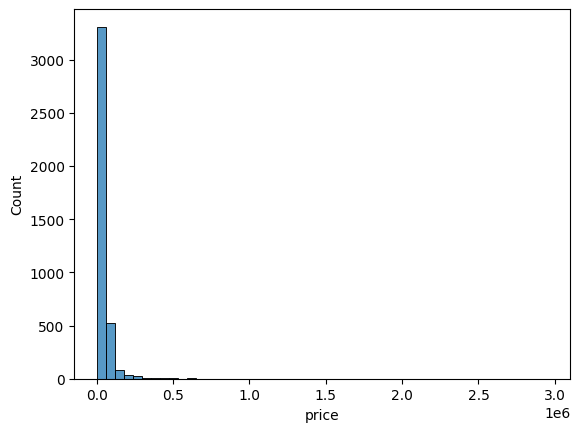

In [148]:
import seaborn as sns
sns.histplot(df_final['price'], bins=50)

In [ ]:

df_final['price'] = np.log(df_final['price'])

<Axes: xlabel='price', ylabel='Count'>

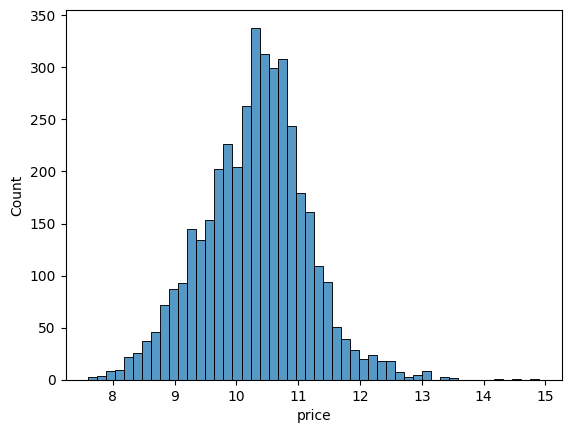

In [ ]:

sns.histplot(df_final['price'], bins=50)

In [151]:
X= df_final.drop('price', axis=1)
y= df_final['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [152]:
# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# 1. MAE
mae = mean_absolute_error(y_test, y_pred)

# 2. RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 3. R^2 Score
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE: $0.29
RMSE: $0.45
R2 Score: 0.7433


In [153]:
# Initialize 
rf_model = RandomForestRegressor(random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict & Evaluate
y_pred_df = rf_model.predict(X_test)
print(f"Default RF R2: {r2_score(y_test, y_pred_df):.4f}")

Default RF R2: 0.8108


In [ ]:
# 1. Initialize the model

xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)

# 2. Train the model
xgb_model.fit(X_train, y_train)

# 3. Predict
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate
print(f"XGB MAE: ${mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"XGB R2 Score: {r2_score(y_test, y_pred_xgb):.4f}")

XGB MAE: $0.22
XGB R2 Score: 0.8286


In [155]:
import joblib

# 1. Save the Linear model to a file
joblib.dump(lr_model, 'lr_model.pkl')

# 2. Save the Random forest model to a file
joblib.dump(rf_model, 'rf_model.pkl')

# 3. Save the XGBoost model to a file
joblib.dump(xgb_model, 'xgb_model.pkl')

print("Model saved successfully ")

Model saved successfully 
